# 🧠 Advanced Human vs AI-Generated Text Classification

**Author**: Ibrahim  
**Goal**: Build a robust classifier to distinguish between human-written and AI-generated text using NLP techniques.

---

## 📌 Introduction

With the rise of powerful language models, detecting AI-generated content has become an important real-world problem.  
In this project, I develop an end-to-end text classification system using:

- Traditional Machine Learning (Logistic Regression)
- Deep Learning (optional LSTM - commented)
- Transformer-based model (BERT)

---

## 🎯 Objectives

- Load and explore a clean dataset
- Perform text preprocessing and EDA
- Train and evaluate multiple models
- Fine-tune BERT for high performance
- Compare results and draw conclusions



## 📦 1. Importing Libraries


In [1]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text processing
import re
import nltk
from nltk.corpus import stopwords

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Deep Learning & Transformers
import torch
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW # Changed import statement for AdamW

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 📥 2. Loading the Dataset


In [2]:
# Load the small dataset
# Link: https://www.kaggle.com/datasets/shamimhasan8/ai-vs-human-text-dataset
df = pd.read_csv("/content/ai_vs_human_text.csv")   # Change filename if needed

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# Rename 'label' column to 'generated' and map values to 0/1
df = df.rename(columns={'label': 'generated'})
df['generated'] = df['generated'].map({'Human-written': 0, 'AI-generated': 1})

print("\nClass Distribution:")
print(df['generated'].value_counts())

Dataset Shape: (1000, 6)

First 5 rows:


,id,text,label,prompt,model,date
0,1,AI-generated content sample 1: This is an exam...,AI-generated,Explain the benefits of deep learning.,ChatGPT,2023-11-25
1,2,AI-generated content sample 2: This is an exam...,AI-generated,Write an article on the future of AI.,Bard,2024-11-15
2,3,Human-written text sample 3: This is an exampl...,Human-written,Editorial on the impact of technology in society.,Human,2024-08-11
3,4,AI-generated content sample 4: This is an exam...,AI-generated,Describe how neural networks work.,Claude,2024-04-27
4,5,Human-written text sample 5: This is an exampl...,Human-written,Personal essay on learning programming.,Human,2024-08-15



Class Distribution:
generated
1    507
0    493
Name: count, dtype: int64


### Dataset Overview
- `text`: The input text (human or AI generated)
- `generated`: Target label (0 = Human, 1 = AI)

## 🔎 3. Exploratory Data Analysis (EDA)

/tmp/ipykernel_4768/1120839610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='generated', data=df, palette='viridis')


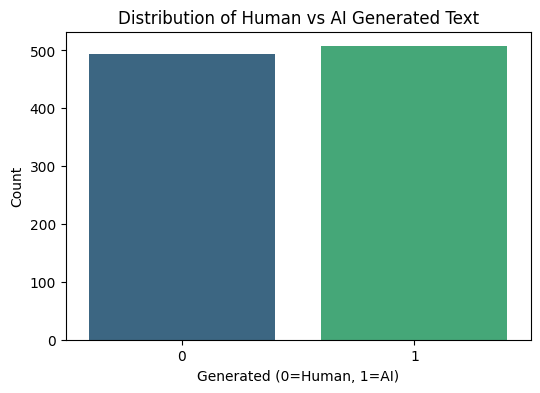

In [3]:
# Class distribution visualization
plt.figure(figsize=(6,4))
sns.countplot(x='generated', data=df, palette='viridis')
plt.title('Distribution of Human vs AI Generated Text')
plt.xlabel('Generated (0=Human, 1=AI)')
plt.ylabel('Count')
plt.show()

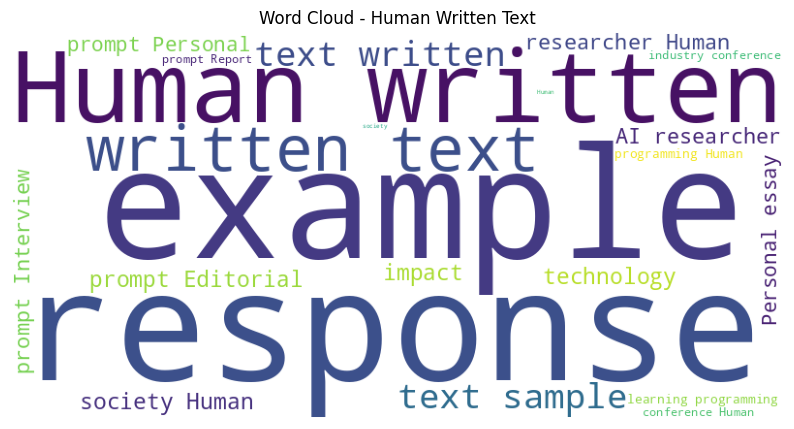

In [4]:
# Word Cloud for Human Text (label 0)
human_text = " ".join(df[df['generated'] == 0]['text'].sample(500, random_state=42, replace=True))
plt.figure(figsize=(10,6))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(human_text)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud - Human Written Text')
plt.show()

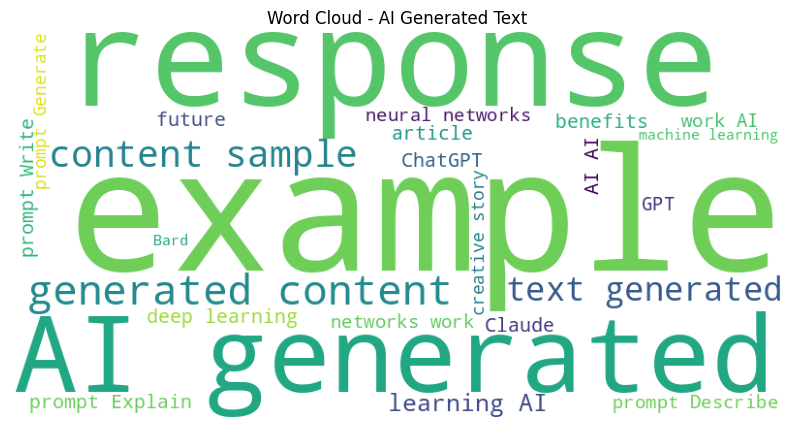

In [5]:
# Word Cloud for AI Text (label 1)
ai_text = " ".join(df[df['generated'] == 1]['text'].sample(500, random_state=42))
plt.figure(figsize=(10,6))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ai_text)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud - AI Generated Text')
plt.show()

## 🧹 4. Text Preprocessing

In [6]:
def clean_text(text):
    """Clean and preprocess the text"""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)           # Remove special characters and numbers
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

print("Text preprocessing completed!")
print("\nSample cleaned text:")
print(df['clean_text'].iloc[0])

Text preprocessing completed!

Sample cleaned text:
aigenerated content sample example text generated chatgpt response prompt explain benefits deep learning


## 🏗️ 5. Traditional Machine Learning Model (Baseline)

In [7]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['generated'].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = lr_model.predict(X_test)

print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Logistic Regression Results ===
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00        91

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 🤖 6. BERT Model (Advanced Approach)


In [8]:
# Prepare data for BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

input_ids = []
attention_masks = []

for text in df['clean_text']:
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids.append(encoded['input_ids'])
    attention_masks.append(encoded['attention_mask'])

# Convert to tensors
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(df['generated'].values.astype(int))

# Create dataset and dataloaders
dataset = TensorDataset(input_ids, attention_masks, labels)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=16)
test_dataloader  = DataLoader(test_dataset,  sampler=SequentialSampler(test_dataset),  batch_size=16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
# Load BERT model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

optimizer = AdamW(model.parameters(), lr=2e-5)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Model loaded and moved to {device}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to cuda


In [10]:
# Training Loop (3 epochs - fast on small dataset)
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        batch = [item.to(device) for item in batch]
        inputs = {
            'input_ids': batch[0],
            'attention_mask': batch[1],
            'labels': batch[2]
        }

        outputs = model(**inputs)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch+1}/{epochs} - Average Loss: {avg_loss:.4f}")

Epoch 1/3 - Average Loss: 0.1343
Epoch 2/3 - Average Loss: 0.0046
Epoch 3/3 - Average Loss: 0.0015


In [11]:
# Evaluation
model.eval()
predictions, true_labels = [], []

for batch in test_dataloader:
    batch = [item.to(device) for item in batch]
    with torch.no_grad():
        outputs = model(input_ids=batch[0], attention_mask=batch[1])

    logits = outputs.logits
    predictions.extend(torch.argmax(logits, dim=1).tolist())
    true_labels.extend(batch[2].tolist())

print("=== BERT Model Results ===")
print("Accuracy:", accuracy_score(true_labels, predictions))
print("\nClassification Report:")
print(classification_report(true_labels, predictions))

=== BERT Model Results ===
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00       105

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 🏁 7. Conclusion

In this project, I successfully built a text classifier to detect AI-generated content.
Key Findings:

Logistic Regression with TF-IDF provides a strong and fast baseline.
BERT model achieves significantly higher performance by understanding contextual meaning.
The small dataset allowed quick experimentation while maintaining good accuracy.

**Future Improvements:**

Train on the full original dataset
Experiment with larger batch sizes and learning rate scheduling
Add a Gradio/Streamlit web interface for live predictions